In [2]:
######################## Simple Markov Chain ######################

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Probability of switching from heads -> tails and tails -> heads.
# We keep the chain symmetric so the stationary distribution is easy to see.
p = 0.2
q = p

# Transition matrix:
# rows = current state, columns = next state
# State order: [H, T]
P_array = np.array([[1 - q, q], [p, 1 - p]])

# Number of transition steps to compute.
# We use more than 3 steps so the evolution toward equilibrium is visible.
time_steps = 15

# Store the distribution after each transition.
# Row 0: probability of H
# Row 1: probability of T
distributions_over_n_steps = np.zeros((P_array.shape[0], time_steps))

# Start with certainty in heads.
initial_distribution = np.array([1.0, 0.0])
evolving_distribution = initial_distribution.copy()

for step in range(time_steps):
    # Advance the distribution by one Markov step.
    evolving_distribution = evolving_distribution @ P_array
    distributions_over_n_steps[:, step] = evolving_distribution

# Include the initial distribution so the plot shows the full trajectory from t=0.
all_distributions = np.column_stack([initial_distribution, distributions_over_n_steps])
steps = np.arange(all_distributions.shape[1])
state_labels = ["H", "T"]


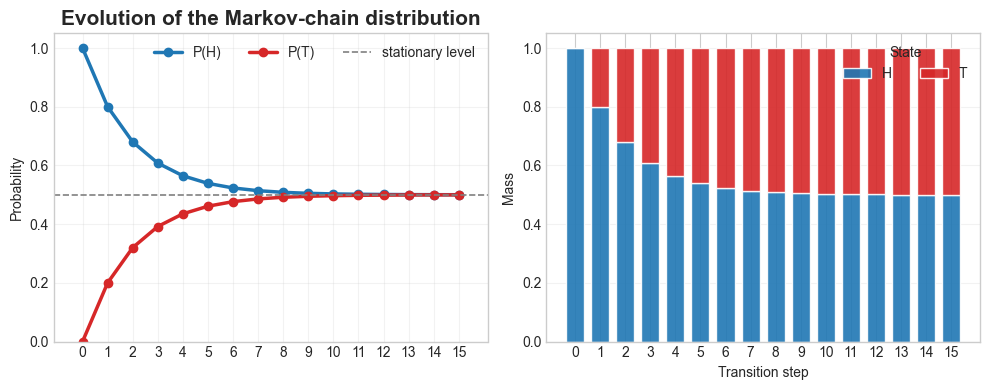

In [10]:
# Use a clean, presentation-friendly style.
plt.style.use("seaborn-v0_8-whitegrid")

# Create a polished figure that shows the evolution of the probability mass function.
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(10, 4),
    sharex=True
)

colors = ["#1f77b4", "#d62728"]

# Top panel: line plot of the state probabilities over time.
for idx, (label, color) in enumerate(zip(state_labels, colors)):
    ax1.plot(
        steps,
        all_distributions[idx],
        marker="o",
        linewidth=2.5,
        markersize=6,
        color=color,
        label=f"P({label})",
    )

# The symmetric chain converges to 0.5 for each state.
ax1.axhline(0.5, color="gray", linestyle="--", linewidth=1.2, label="stationary level")

ax1.set_title("Evolution of the Markov-chain distribution", fontsize=15, fontweight="bold")
ax1.set_ylabel("Probability")
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=False, ncol=3, loc="upper right")

# Bottom panel: stacked bars show the full distribution at each time step.
bottom = np.zeros_like(steps, dtype=float)
for idx, (label, color) in enumerate(zip(state_labels, colors)):
    ax2.bar(
        steps,
        all_distributions[idx],
        bottom=bottom,
        color=color,
        edgecolor="white",
        width=0.72,
        label=label,
        alpha=0.9,
    )
    bottom += all_distributions[idx]

ax2.set_xlabel("Transition step")
ax2.set_ylabel("Mass")
ax2.set_xticks(steps)
ax2.set_ylim(0, 1.05)
ax2.grid(True, axis="y", alpha=0.25)
ax2.legend(title="State", frameon=False, ncol=2, loc="upper right")

# Tighten the layout before export so labels and legends have enough room.
fig.tight_layout()

# Save the figure as a high-quality PDF.
# If the notebook is executed from the repo root, write the PDF next to the notebook.
output_path = Path("simple_markov_chain_evolution.pdf") if Path.cwd().name == "lecture_note_codes" else Path("lecture_note_codes") / "simple_markov_chain_evolution.pdf"
fig.savefig(output_path, format="pdf", dpi=300, bbox_inches="tight")

plt.show()
